# NCA 2D Dataset Visualization

Visualize datasets generated by `data/build_nca2d_dataset.py`.

- `input_ids` are stored as a padded flattened tensor shaped like `[H, W, 2C+1]`
- Channels are ordered as `example_1_input, example_1_label, ..., example_C_input, example_C_label, query_input`
- `labels` are stored in a PuzzleDataset-compatible flat array, with the query answer written onto the same channel index as `query_input`
- `H`, `W`, and `C` can vary per sample, so the notebook decodes each example using the per-sample metadata

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import data.build_nca2d_dataset as build_nca2d_dataset
from data.common import PuzzleDatasetMetadata

build_nca2d_dataset = importlib.reload(build_nca2d_dataset)

DATA_DIR = Path(os.environ.get("NCA2D_DATA_DIR", str(REPO_ROOT / "data" / "nca2d")))
AUTO_BUILD_IF_MISSING = False

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)


REPO_ROOT: /workspaces/URM2
DATA_DIR: /workspaces/URM2/data/nca2d


In [2]:
if AUTO_BUILD_IF_MISSING or not (DATA_DIR / "config.json").exists():
    config = build_nca2d_dataset.NCA2DDataConfig(
        output_dir=str(DATA_DIR),
        train_size=800,
        test_size=200,
        seed=42,
        state_height=12,
        state_height_min=8,
        state_height_max=12,
        state_width=12,
        state_width_min=8,
        state_width_max=12,
        num_colors=10,
        patch_size=1,
        answer_steps=4,
        answer_steps_min=2,
        answer_steps_max=4,
        counts=3,
        counts_min=1,
        counts_max=3,
        time_start=24,
        time_span=1,
        gzip_threshold_low=None,
        gzip_threshold_high=None,
        batch_candidate_size=256,
        max_sampling_rounds=20,
        max_cells_per_candidate_batch=4_000_000,
        save_dtype="int32",
    )
    build_nca2d_dataset.build_dataset(config)
    print("Built dataset at", DATA_DIR)
else:
    print("Using existing dataset at", DATA_DIR)


Using existing dataset at /workspaces/URM2/data/nca2d


In [ ]:
with open(DATA_DIR / "config.json") as f:
    builder_config = json.load(f)

def load_optional_array(path: Path):
    return np.load(path) if path.exists() else None

def load_split(split: str):
    split_dir = DATA_DIR / split
    with open(split_dir / "dataset.json") as f:
        metadata = PuzzleDatasetMetadata(**json.load(f))

    dataset = {
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "position_ids": load_optional_array(split_dir / "all__position_ids.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "gzip_ratio": load_optional_array(split_dir / "all__gzip_ratio.npy"),
        "state_heights": load_optional_array(split_dir / "all__state_heights.npy"),
        "state_widths": load_optional_array(split_dir / "all__state_widths.npy"),
        "answer_steps": load_optional_array(split_dir / "all__answer_steps.npy"),
        "counts": load_optional_array(split_dir / "all__counts.npy"),
        "input_channels": load_optional_array(split_dir / "all__input_channels.npy"),
        "query_channel_indices": load_optional_array(split_dir / "all__query_channel_indices.npy"),
    }
    return metadata, dataset

# train_meta, train_data = load_split("train")
test_meta, test_data = load_split("test")

print("Builder config:")
print(json.dumps(builder_config, indent=2))
# print()
# print("Train metadata:")
# print(train_meta.model_dump())
print()
print("Test metadata:")
print(test_meta.model_dump())


KeyboardInterrupt: 

In [ ]:
# print("Train arrays:")
# for key, value in train_data.items():
#     if value is None:
#         print(f"  {key:20s} None")
#     else:
#         print(f"  {key:20s} shape={value.shape} dtype={value.dtype}")

# print()
print("Test arrays:")
for key, value in test_data.items():
    if value is None:
        print(f"  {key:20s} None")
    else:
        print(f"  {key:20s} shape={value.shape} dtype={value.dtype}")


Train arrays:
  inputs               shape=(800, 1008) dtype=int32
  labels               shape=(800, 1008) dtype=int32
  position_ids         shape=(800, 1008, 3) dtype=int32
  puzzle_identifiers   shape=(800,) dtype=int32
  puzzle_indices       shape=(801,) dtype=int32
  group_indices        shape=(801,) dtype=int32
  gzip_ratio           shape=(800,) dtype=float32
  state_heights        shape=(800,) dtype=int32
  state_widths         shape=(800,) dtype=int32
  answer_steps         shape=(800,) dtype=int32
  counts               shape=(800,) dtype=int32
  input_channels       shape=(800,) dtype=int32
  query_channel_indices shape=(800,) dtype=int32

Test arrays:
  inputs               shape=(200, 1008) dtype=int32
  labels               shape=(200, 1008) dtype=int32
  position_ids         shape=(200, 1008, 3) dtype=int32
  puzzle_identifiers   shape=(200,) dtype=int32
  puzzle_indices       shape=(201,) dtype=int32
  group_indices        shape=(201,) dtype=int32
  gzip_ratio         

In [ ]:
DEFAULT_COLORS = [
    "#ff0000", "#00ff00", "#0000ff", "#ffff00", "#ff00ff",
    "#00ffff", "#ffffff", "#8f5d00", "#444444", "#ff8800",
]

def make_discrete_cmap(num_colors: int) -> mcolors.ListedColormap:
    if num_colors <= len(DEFAULT_COLORS):
        cols = DEFAULT_COLORS[:num_colors]
    else:
        cols = [plt.cm.tab20(i / max(1, num_colors - 1)) for i in range(num_colors)]
    return mcolors.ListedColormap(cols)

NUM_COLORS = int(builder_config.get("resolved_out_colors", builder_config["num_colors"]))
TOKEN_OFFSET = int(builder_config["token_offset"])
PADDED_HEIGHT, PADDED_WIDTH, PADDED_CHANNELS = map(int, builder_config["final_image_shape"])
CMAP = make_discrete_cmap(NUM_COLORS)

def sample_counts(dataset, sample_idx: int) -> int:
    value = dataset["counts"]
    return int(value[sample_idx]) if value is not None else 1

def sample_height(dataset, sample_idx: int) -> int:
    value = dataset["state_heights"]
    return int(value[sample_idx]) if value is not None else PADDED_HEIGHT

def sample_width(dataset, sample_idx: int) -> int:
    value = dataset["state_widths"]
    return int(value[sample_idx]) if value is not None else PADDED_WIDTH

def sample_answer_steps(dataset, sample_idx: int) -> int:
    value = dataset["answer_steps"]
    return int(value[sample_idx]) if value is not None else int(builder_config["answer_steps"])

def decode_input_grid(dataset, sample_idx: int) -> np.ndarray:
    image_height = sample_height(dataset, sample_idx)
    image_width = sample_width(dataset, sample_idx)
    counts = sample_counts(dataset, sample_idx)
    return build_nca2d_dataset.unflatten_input_grid(
        np.asarray(dataset["inputs"][sample_idx]),
        image_height=image_height,
        image_width=image_width,
        counts=counts,
        token_offset=TOKEN_OFFSET,
        padded_height=PADDED_HEIGHT,
        padded_width=PADDED_WIDTH,
        padded_channels=PADDED_CHANNELS,
    )

def decode_label_grid(dataset, sample_idx: int) -> np.ndarray:
    image_height = sample_height(dataset, sample_idx)
    image_width = sample_width(dataset, sample_idx)
    counts = sample_counts(dataset, sample_idx)
    return build_nca2d_dataset.extract_label_grid(
        np.asarray(dataset["labels"][sample_idx]),
        image_height=image_height,
        image_width=image_width,
        counts=counts,
        token_offset=TOKEN_OFFSET,
        padded_height=PADDED_HEIGHT,
        padded_width=PADDED_WIDTH,
        padded_channels=PADDED_CHANNELS,
    )

def sample_info(dataset, sample_idx: int) -> dict:
    counts = sample_counts(dataset, sample_idx)
    return {
        "height": sample_height(dataset, sample_idx),
        "width": sample_width(dataset, sample_idx),
        "counts": counts,
        "input_channels": 2 * counts + 1,
        "query_channel_index": 2 * counts,
        "answer_steps": sample_answer_steps(dataset, sample_idx),
        "gzip_ratio": None if dataset["gzip_ratio"] is None else float(dataset["gzip_ratio"][sample_idx]),
    }

def plot_sample(dataset, sample_idx: int, split_name: str = "train") -> None:
    info = sample_info(dataset, sample_idx)
    input_grid = decode_input_grid(dataset, sample_idx)
    label_grid = decode_label_grid(dataset, sample_idx)
    counts = info["counts"]
    cols = counts + 1
    fig, axes = plt.subplots(2, cols, figsize=(3.0 * cols, 6.0), squeeze=False)

    for example_idx in range(counts):
        axes[0, example_idx].imshow(input_grid[:, :, 2 * example_idx], cmap=CMAP, vmin=0, vmax=NUM_COLORS - 1, interpolation="nearest")
        axes[0, example_idx].set_title(f"Example {example_idx + 1} input")
        axes[1, example_idx].imshow(input_grid[:, :, 2 * example_idx + 1], cmap=CMAP, vmin=0, vmax=NUM_COLORS - 1, interpolation="nearest")
        axes[1, example_idx].set_title(f"Example {example_idx + 1} label")

    axes[0, -1].imshow(input_grid[:, :, -1], cmap=CMAP, vmin=0, vmax=NUM_COLORS - 1, interpolation="nearest")
    axes[0, -1].set_title("Query input")
    axes[1, -1].imshow(label_grid[:, :, 0], cmap=CMAP, vmin=0, vmax=NUM_COLORS - 1, interpolation="nearest")
    axes[1, -1].set_title("Query label")

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    subtitle = (
        f"{split_name}[{sample_idx}]  "
        f"H={info['height']} W={info['width']} C={info['counts']}  "
        f"input_channels={info['input_channels']}  answer_steps={info['answer_steps']}"
    )
    if info["gzip_ratio"] is not None and info["gzip_ratio"] >= 0.0:
        subtitle += f"  gzip={info['gzip_ratio']:.4f}"

    fig.suptitle(subtitle)
    plt.tight_layout()
    plt.show()


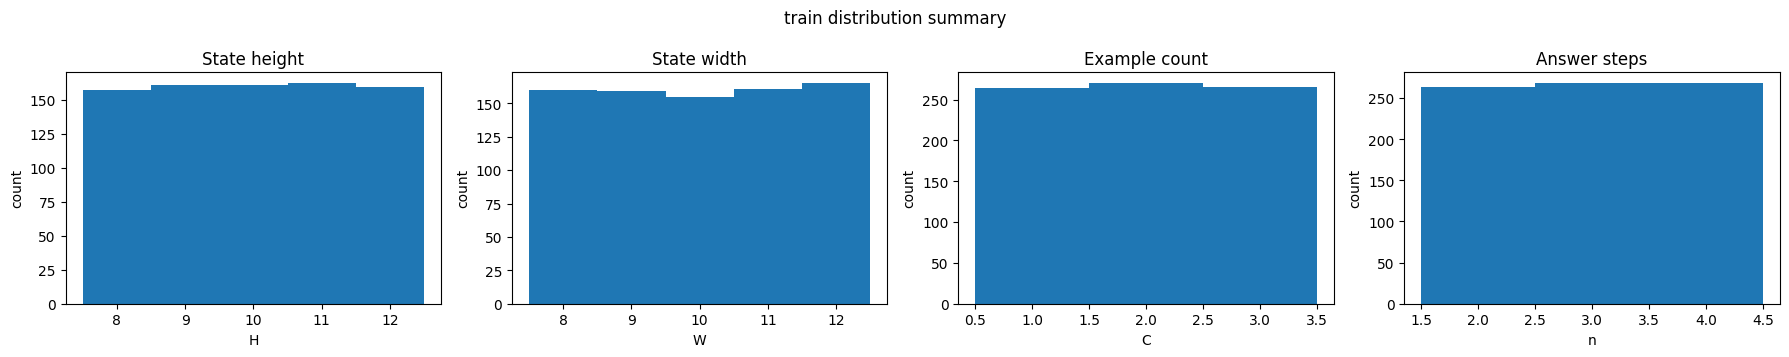

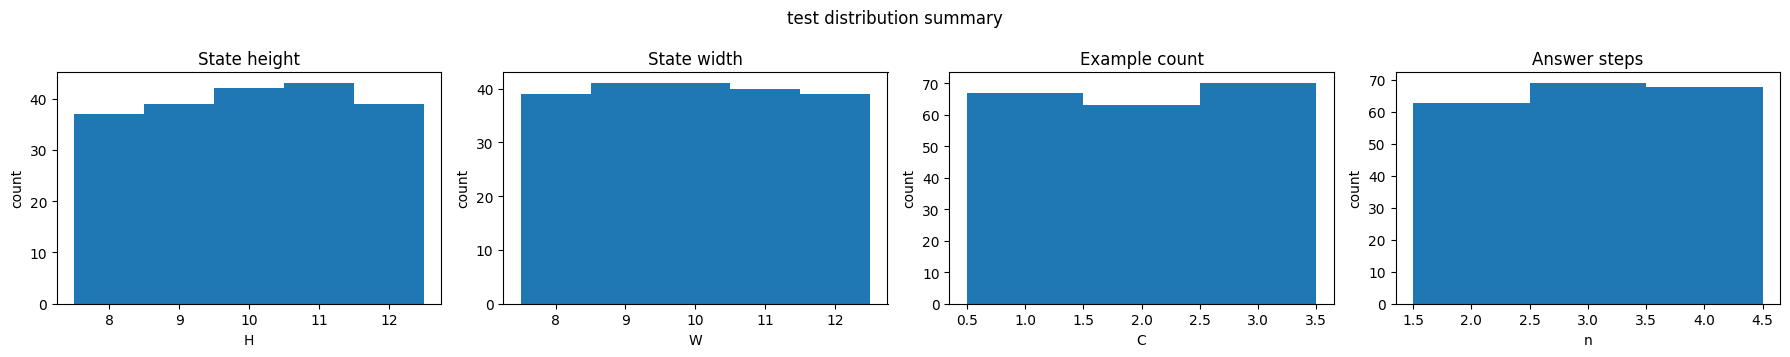

In [ ]:
def plot_split_distributions(dataset, split_name: str) -> None:
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
    fig.suptitle(f"{split_name} distribution summary")

    axes[0].hist(dataset["state_heights"], bins=np.arange(dataset["state_heights"].min(), dataset["state_heights"].max() + 2) - 0.5)
    axes[0].set_title("State height")
    axes[0].set_xlabel("H")

    axes[1].hist(dataset["state_widths"], bins=np.arange(dataset["state_widths"].min(), dataset["state_widths"].max() + 2) - 0.5)
    axes[1].set_title("State width")
    axes[1].set_xlabel("W")

    axes[2].hist(dataset["counts"], bins=np.arange(dataset["counts"].min(), dataset["counts"].max() + 2) - 0.5)
    axes[2].set_title("Example count")
    axes[2].set_xlabel("C")

    axes[3].hist(dataset["answer_steps"], bins=np.arange(dataset["answer_steps"].min(), dataset["answer_steps"].max() + 2) - 0.5)
    axes[3].set_title("Answer steps")
    axes[3].set_xlabel("n")

    for ax in axes:
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

# plot_split_distributions(train_data, "train")
plot_split_distributions(test_data, "test")


In [ ]:
rng = np.random.default_rng(0)
sample_indices = rng.choice(len(test_data["inputs"]), size=6, replace=False)
sample_indices


array([215, 507, 407, 245,  32, 676])

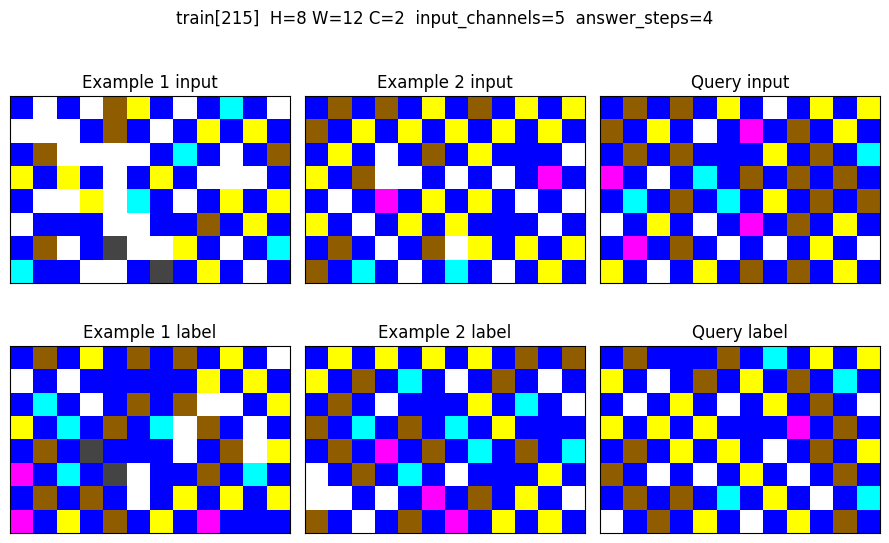

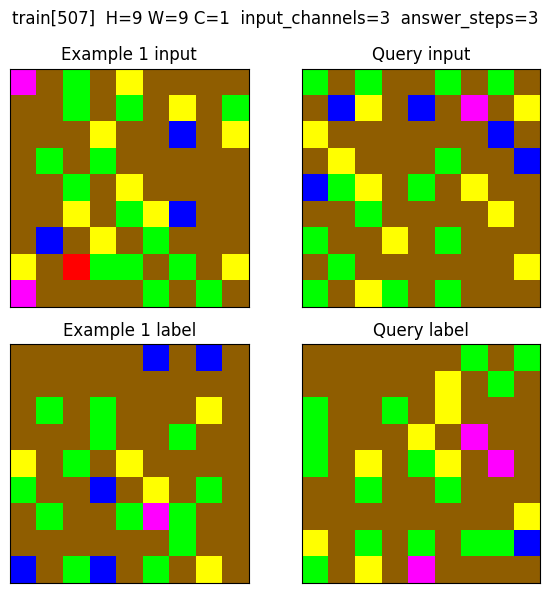

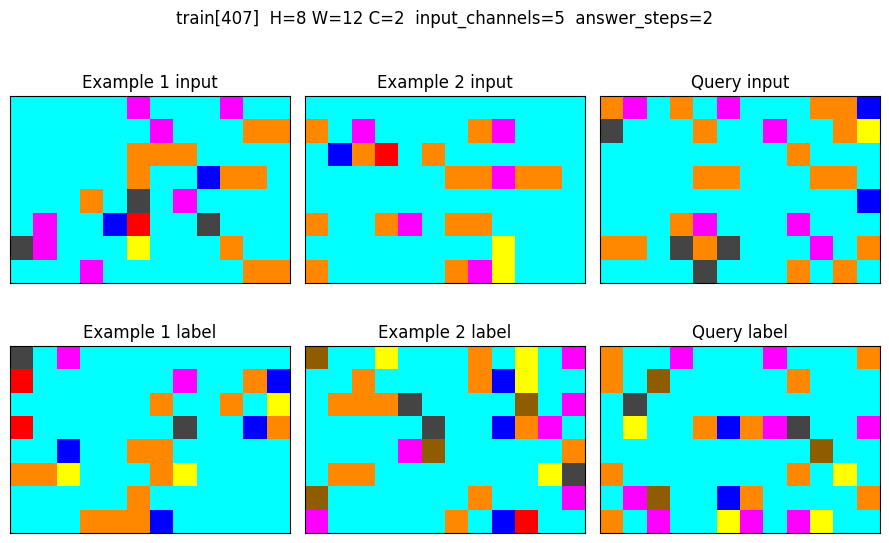

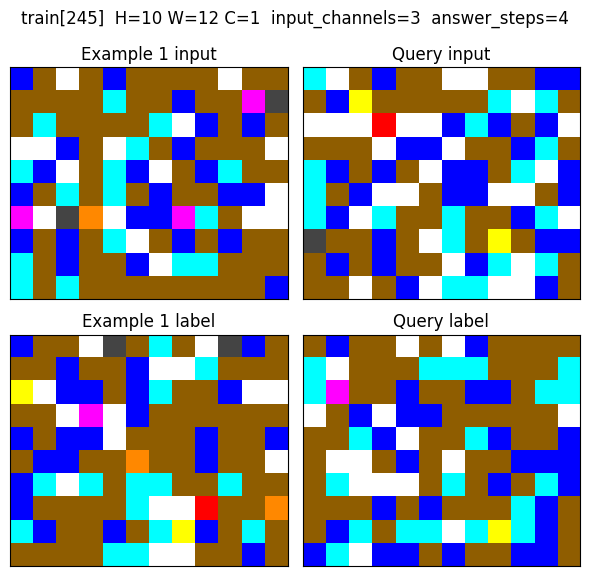

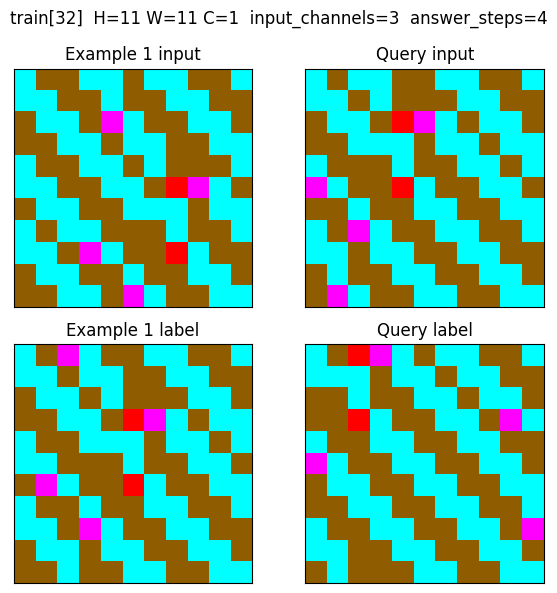

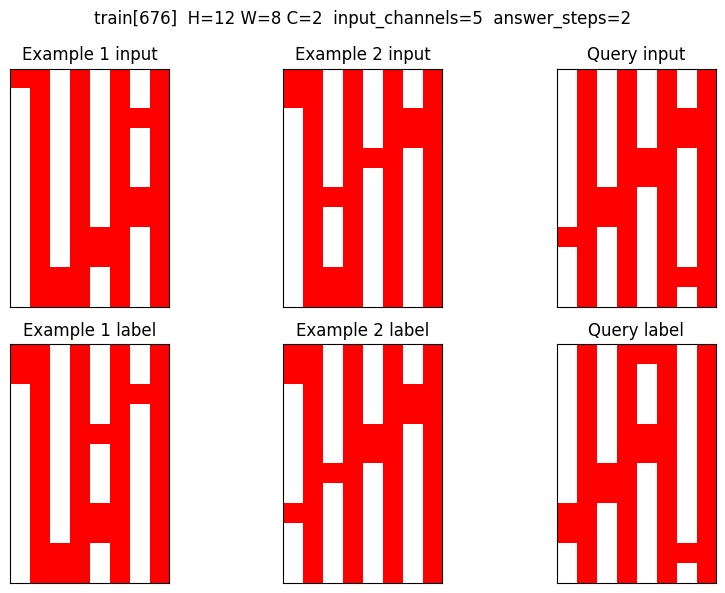

In [ ]:
for sample_idx in sample_indices:
    plot_sample(test_data, int(sample_idx), split_name="test")


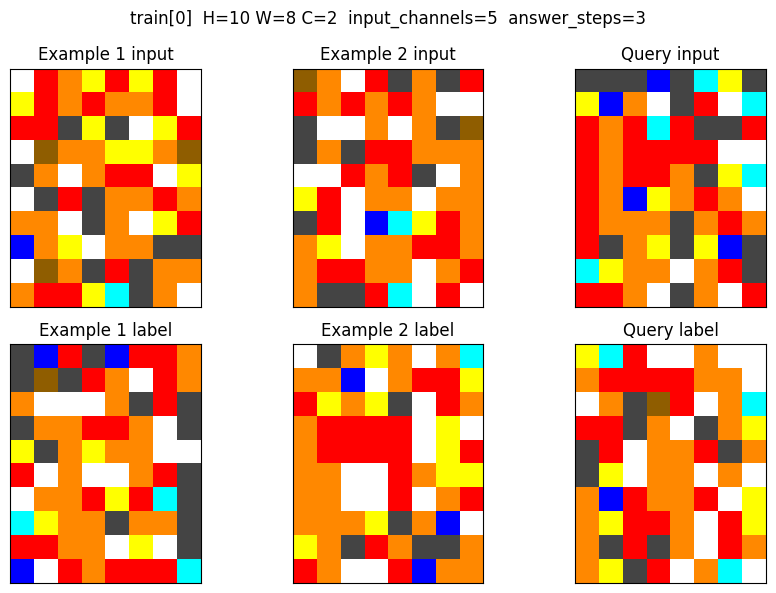

In [ ]:
# Set this to any valid test index for a closer look.
FOCUS_INDEX = 0
plot_sample(test_data, FOCUS_INDEX, split_name="test")
